# BERT Baseline Experiment
Raw proof-of-concept notebook — not production code.
Goal: verify BERT fine-tuning works on BBC News dataset
and establish a baseline accuracy before modularising.

In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
from pathlib import Path
from google.cloud import bigquery
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import json

In [3]:
# verify GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

Device: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU


In [4]:
PROJECT = "cs-cdwp-data-dev2188"
TABLE   = "bigquery-public-data.bbc_news.fulltext"

client = bigquery.Client(project=PROJECT)

query = f"""
    SELECT body, title, category
    FROM `{TABLE}`
    ORDER BY RAND()
    LIMIT 1000
"""

df = client.query(query).to_dataframe()

print(f"Shape: {df.shape}")
print(f"Categories: {df['category'].unique()}")
df.head()

Shape: (1000, 3)
Categories: ['politics' 'business' 'tech' 'sport' 'entertainment']


,body,title,category
0,A group of MPs has tried to raise the pressure...,MPs tout Lords replacement plan,politics
1,As the Aurora limped back to its dock on 20 Ja...,Market unfazed by Aurora setback,business
2,Details of the chip designed to power Sony's P...,PlayStation 3 chip to be unveiled,tech
3,The Lib Dems are set for their best results in...,Lib Dems predict 'best ever poll',politics
4,"Singapore's economy grew by 8.1% in 2004, its ...",Singapore growth at 8.1% in 2004,business


In [5]:
LABEL2ID = {
    "business":      0,
    "entertainment": 1,
    "politics":      2,
    "sport":         3,
    "tech":          4,
}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

df["label"] = df["category"].map(LABEL2ID)

print("Label distribution:")
print(df["label"].value_counts().sort_index())

Label distribution:
label
0    224
1    172
2    195
3    230
4    179
Name: count, dtype: int64


In [6]:
# first split off test set (10%)
train_val_df, test_df = train_test_split(
    df,
    test_size=0.1,
    random_state=42,
    stratify=df["label"]   # preserve class distribution in each split
)

# then split train and val (10% of remaining)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.111,       # 0.111 of 90% ≈ 10% of total
    random_state=42,
    stratify=train_val_df["label"]
)

print(f"Train : {len(train_df):,} samples")
print(f"Val   : {len(val_df):,} samples")
print(f"Test  : {len(test_df):,} samples")
print(f"Total : {len(df):,} samples")

Train : 800 samples
Val   : 100 samples
Test  : 100 samples
Total : 1,000 samples


In [7]:
# go up one level from notebooks/ to project root
PROJECT_ROOT = Path(os.getcwd()).parent
LOCAL_MODEL_PATH = PROJECT_ROOT / "models" / "base-models" / "bert-base-uncased"
MAX_LENGTH   = 512
HEAD_TOKENS  = 340    # 2/3 of 510 usable tokens
TAIL_TOKENS  = 170    # 1/3 of 510 usable tokens

tokenizer = BertTokenizer.from_pretrained(LOCAL_MODEL_PATH, local_files_only=True)
print(f"Vocab size: {tokenizer.vocab_size:,}")

Vocab size: 30,522


In [8]:
class BBCNewsDataset(Dataset):
    
    def __init__(
        self,
        df,
        tokenizer,
        max_length:   int = 512,
        head_tokens:  int = 340,
        tail_tokens:  int = 170,
    ):
        self.texts       = df["body"].tolist()
        self.labels      = df["label"].tolist()
        self.tokenizer   = tokenizer
        self.max_length  = max_length
        self.head_tokens = head_tokens
        self.tail_tokens = tail_tokens

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):          # ← indented inside class
        text  = self.texts[idx]
        label = self.labels[idx]

        tokens = self.tokenizer.encode(
            text,
            add_special_tokens=False,
            truncation=False,
        )

        if len(tokens) > (self.head_tokens + self.tail_tokens):
            tokens = tokens[:self.head_tokens] + tokens[-self.tail_tokens:]

        tokens = (
            [self.tokenizer.cls_token_id]
            + tokens
            + [self.tokenizer.sep_token_id]
        )

        padding_length = self.max_length - len(tokens)
        attention_mask = [1] * len(tokens) + [0] * padding_length
        tokens         = tokens + [self.tokenizer.pad_token_id] * padding_length

        return {
            "input_ids":      torch.tensor(tokens,         dtype=torch.long),
            "attention_mask": torch.tensor(attention_mask, dtype=torch.long),
            "label":          torch.tensor(label,          dtype=torch.long)
        }

In [9]:
# create datasets
train_dataset = BBCNewsDataset(train_df, tokenizer)
val_dataset   = BBCNewsDataset(val_df,   tokenizer)
test_dataset  = BBCNewsDataset(test_df,  tokenizer)

In [10]:
# create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,        # shuffle every epoch
    num_workers=0,       # 0 for Windows — avoids multiprocessing issues
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,       # no shuffle for val/test
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
)

In [11]:
# verify one batch
batch = next(iter(train_loader))
print(f"input_ids shape      : {batch['input_ids'].shape}")
print(f"attention_mask shape : {batch['attention_mask'].shape}")
print(f"labels shape         : {batch['label'].shape}")
print(f"label values         : {batch['label']}")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (891 > 512). Running this sequence through the model will result in indexing errors


input_ids shape      : torch.Size([16, 512])
attention_mask shape : torch.Size([16, 512])
labels shape         : torch.Size([16])
label values         : tensor([4, 1, 2, 3, 2, 4, 4, 0, 1, 3, 1, 0, 1, 3, 0, 2])


In [12]:
model = BertForSequenceClassification.from_pretrained(
    LOCAL_MODEL_PATH,
    num_labels=5,
    local_files_only=True,
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [14]:
# move to GPU
model = model.to(device)

# verify
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total params    : {total_params:,}")
print(f"Trainable params: {trainable_params:,}")
print(f"Model device    : {next(model.parameters()).device}")

Total params    : 109,486,085
Trainable params: 109,486,085
Model device    : cuda:0


## Optimizer and Scheduler — Technical Reference

### AdamW Optimizer

**Adam** stands for **Adaptive Moment Estimation**. It maintains two moving averages per parameter:

```
m_t = β1 * m_{t-1} + (1 - β1) * g_t        ← 1st moment (mean of gradients)
v_t = β2 * v_{t-1} + (1 - β2) * g_t²       ← 2nd moment (variance of gradients)

parameter update:
θ_t = θ_{t-1} - lr * m_t / (√v_t + ε)
```

In plain terms:
```
m_t  → which direction are gradients consistently pointing?
v_t  → how much are gradients jumping around?

update = lr * direction / noise
         ↑                ↑
         go this way    but scale down if noisy
```

This means:
- Parameters with **consistent gradients** → take bigger steps
- Parameters with **noisy gradients** → take smaller steps
- Each parameter gets its **own adaptive learning rate**

**The W in AdamW — Weight Decay:**

Original Adam had a bug with L2 regularization:
```
# Adam (buggy L2)
gradient = gradient + weight_decay * parameter   # adds to gradient
update   = adam_update(gradient)                 # adaptive scaling distorts it

# AdamW (correct weight decay)
gradient = gradient                              # gradient unchanged
update   = adam_update(gradient)                 # clean adaptive update
parameter = parameter - lr * weight_decay * parameter  # decay applied separately
```

Weight decay prevents overfitting by penalising large weights — pushing them toward zero.  
AdamW applies it correctly, separately from the gradient update.  
This is why BERT papers always use AdamW, not Adam.

---

### Linear Warmup Scheduler

The learning rate follows a schedule — not constant throughout training:

```
Learning Rate
    │
2e-5│         ╱─────────────────────╲
    │        ╱                       ╲
    │       ╱                         ╲
    │      ╱                           ╲
0   │─────╱                             ╲────
    └─────┬──────────────────────────────────▶ Steps
          │         │                  │
       step 0   warmup end          total steps
       lr=0      lr=2e-5              lr=0

       ◄──────►◄──────────────────────────────►
        warmup           linear decay
        100 steps        total_steps - 100
```

**Why warmup?**

At the start of training:
```
model weights are pretrained (BERT)
optimizer moments (m_t, v_t) are zero — not yet calibrated

if lr is high immediately:
    large updates on uncalibrated optimizer
    → destroys pretrained weights
    → catastrophic forgetting
```

Warmup gives the optimizer time to calibrate before taking large steps.  
100 warmup steps is standard for small datasets like ours.

**Why linear decay?**
```
Early training  → higher lr → explore the loss landscape
Late training   → lower lr  → fine-tune, settle into minimum
                               avoid overshooting
```

The scheduler reduces lr linearly from `2e-5` → `0` over all training steps.

---

### Why These Values for BERT

```
lr=2e-5           ← BERT paper recommendation for fine-tuning
                     too high (1e-4) → destroys pretrained weights
                     too low  (1e-6) → too slow to converge

weight_decay=0.01 ← standard for BERT, small regularization

warmup=100        ← ~12% of total steps
                     (800 samples / 16 batch = 50 steps/epoch × 3 epochs = 150 total)
                     standard is 6-10% of total steps

epochs=3          ← BERT paper recommends 2-4 for fine-tuning
                     more epochs → overfitting on small datasets
```

---

### How They Work Together in the Training Loop

```python
for batch in train_loader:

    optimizer.zero_grad()      # clear gradients from last step

    outputs = model(**batch)   # forward pass
    loss    = outputs.loss     # cross entropy loss

    loss.backward()            # compute gradients (backprop)

    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                               # gradient clipping — prevents exploding gradients
                               # clipping at 1.0 is standard for BERT fine-tuning

    optimizer.step()           # AdamW update — adjust weights
    scheduler.step()           # update learning rate for next step
```

`clip_grad_norm_` is critical — if gradients get very large they destabilize training.  
Clipping at 1.0 is the standard value for all BERT fine-tuning tasks.

In [15]:
# hyperparameters — hardcoded for notebook
EPOCHS       = 3
LR           = 2e-5
WARMUP_STEPS = 100
WEIGHT_DECAY = 0.01

total_steps  = len(train_loader) * EPOCHS

optimizer = AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=total_steps,
)

print(f"Total training steps : {total_steps}")
print(f"Warmup steps         : {WARMUP_STEPS}")
print(f"Steps per epoch      : {len(train_loader)}")

Total training steps : 150
Warmup steps         : 100
Steps per epoch      : 50


In [16]:
def train_epoch(model, loader, optimizer, scheduler, device):
    """Run one full training epoch, return average loss and accuracy."""
    
    model.train()   # set model to training mode — enables dropout
    
    total_loss     = 0
    correct        = 0
    total_samples  = 0

    for batch in loader:
        # move batch to GPU
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["label"].to(device)

        # forward pass
        optimizer.zero_grad()
        
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels,
        )

        loss    = outputs.loss
        logits  = outputs.logits

        # backward pass
        loss.backward()
        
        # gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        
        # update weights + lr
        optimizer.step()
        scheduler.step()

        # accumulate metrics
        total_loss    += loss.item()
        preds          = torch.argmax(logits, dim=1)
        correct       += (preds == labels).sum().item()
        total_samples += labels.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = correct / total_samples

    return avg_loss, accuracy


def eval_epoch(model, loader, device):
    """Run evaluation, return average loss and accuracy."""
    
    model.eval()    # set model to eval mode — disables dropout
    
    total_loss    = 0
    correct       = 0
    total_samples = 0

    with torch.no_grad():   # no gradient computation during eval
        for batch in loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["label"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels,
            )

            loss   = outputs.loss
            logits = outputs.logits

            total_loss    += loss.item()
            preds          = torch.argmax(logits, dim=1)
            correct       += (preds == labels).sum().item()
            total_samples += labels.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = correct / total_samples

    return avg_loss, accuracy

In [17]:
best_val_accuracy = 0
history = {
    "train_loss": [], "train_acc": [],
    "val_loss":   [], "val_acc":   [],
}

print(f"Starting training on {device}")
print(f"{'Epoch':<8}{'Train Loss':<14}{'Train Acc':<14}{'Val Loss':<14}{'Val Acc':<14}{'Time'}")
print("-" * 70)

for epoch in range(EPOCHS):
    start = time.time()

    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
    val_loss,   val_acc   = eval_epoch(model, val_loader, device)

    elapsed = time.time() - start

    # save history
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    # get the best model
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        best_model = model
        best_model_found = "✅ best model found"
    else:
        best_model_found = ""

    print(f"{epoch+1:<8}{train_loss:<14.4f}{train_acc:<14.4f}{val_loss:<14.4f}{val_acc:<14.4f}{elapsed:.1f}s {best_model_found}")

print("-" * 70)
print(f"Best val accuracy: {best_val_accuracy:.4f}")

Starting training on cuda
Epoch   Train Loss    Train Acc     Val Loss      Val Acc       Time
----------------------------------------------------------------------
1       1.5570        0.3312        1.2288        0.8000        51.5s ✅ best model found
2       0.8072        0.8912        0.3058        0.9800        50.8s ✅ best model found
3       0.1846        0.9825        0.1488        0.9700        51.1s 
----------------------------------------------------------------------
Best val accuracy: 0.9800


In [18]:
print("Saving best model...")
SAVE_PATH = PROJECT_ROOT / "models" / "bert-bbc-finetuned"

# add this before saving
model.config.id2label = {0: "business", 1: "entertainment", 
                          2: "politics", 3: "sport", 4: "tech"}
model.config.label2id = {v: k for k, v in model.config.id2label.items()}


model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

print("Saved:")
for f in sorted(SAVE_PATH.iterdir()):
    print(f"  {f.name}")

Saving best model...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved:
  config.json
  model.safetensors
  tokenizer.json
  tokenizer_config.json


In [20]:
# load best model
# 1. initialise architecture
model = BertForSequenceClassification.from_pretrained(
    SAVE_PATH,
    num_labels=5,
    local_files_only=True,
)

# move to GPU
model = model.to(device)

test_loss, test_acc = eval_epoch(model, test_loader, device)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Test Loss     : 0.0790
Test Accuracy : 1.0000


In [27]:
# collect all predictions + probabilities on test set
model.eval()
all_preds  = []
all_labels = []
all_probs  = []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["label"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs   = torch.softmax(outputs.logits, dim=1)
        preds   = torch.argmax(outputs.logits,  dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

ID2LABEL = {v: k for k, v in LABEL2ID.items()}

print(classification_report(
    all_labels,
    all_preds,
    target_names=[ID2LABEL[i] for i in range(5)]
))

               precision    recall  f1-score   support

     business       1.00      1.00      1.00        22
entertainment       1.00      1.00      1.00        17
     politics       1.00      1.00      1.00        20
        sport       1.00      1.00      1.00        23
         tech       1.00      1.00      1.00        18

     accuracy                           1.00       100
    macro avg       1.00      1.00      1.00       100
 weighted avg       1.00      1.00      1.00       100



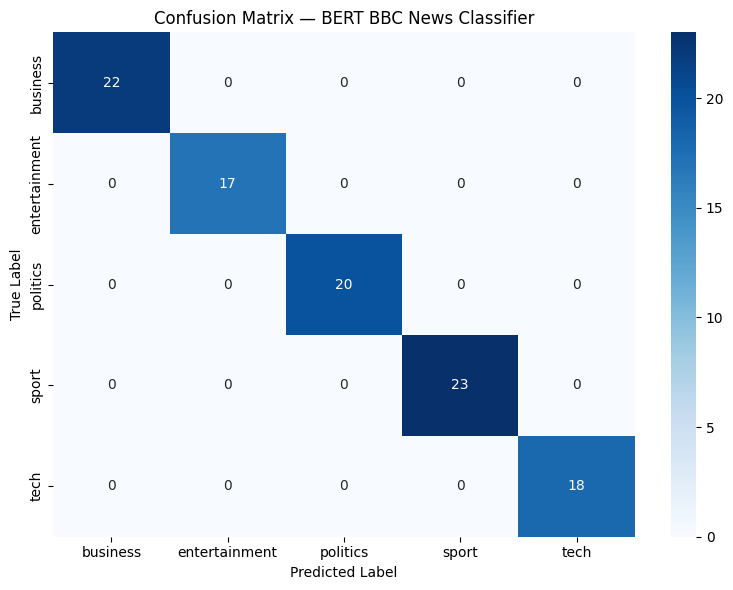

In [22]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[ID2LABEL[i] for i in range(5)],
    yticklabels=[ID2LABEL[i] for i in range(5)],
)
plt.title("Confusion Matrix — BERT BBC News Classifier")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

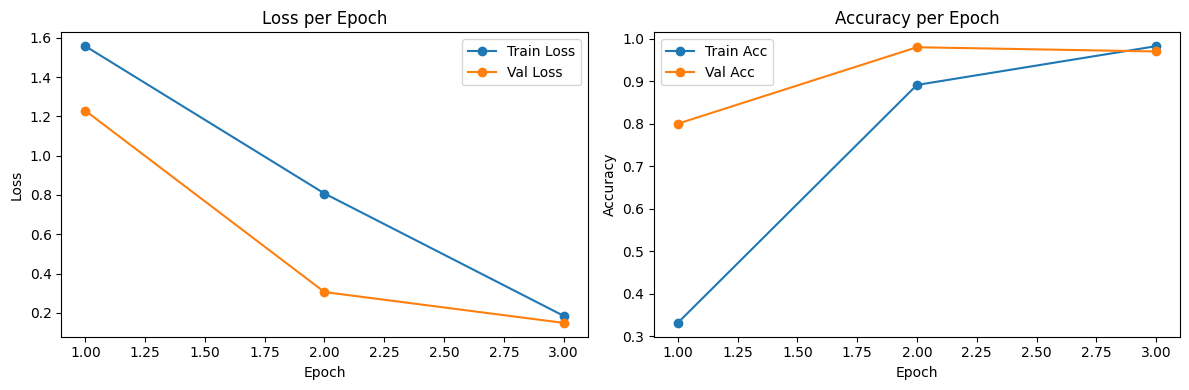

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# loss
ax1.plot(range(1, EPOCHS+1), history["train_loss"], label="Train Loss", marker="o")
ax1.plot(range(1, EPOCHS+1), history["val_loss"],   label="Val Loss",   marker="o")
ax1.set_title("Loss per Epoch")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()

# accuracy
ax2.plot(range(1, EPOCHS+1), history["train_acc"], label="Train Acc", marker="o")
ax2.plot(range(1, EPOCHS+1), history["val_acc"],   label="Val Acc",   marker="o")
ax2.set_title("Accuracy per Epoch")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "figures" / "bert_baseline_training_curves.png", dpi=150)
plt.show()

In [28]:
# build results dataframe
results_df = test_df.copy().reset_index(drop=True)
results_df["true_label"]      = [ID2LABEL[p] for p in all_labels]
results_df["predicted"]       = [ID2LABEL[p] for p in all_preds]
results_df["correct"]         = results_df["true_label"] == results_df["predicted"]
results_df["confidence"]      = [all_probs[i][all_preds[i]]  for i in range(len(all_preds))]
results_df["true_confidence"] = [all_probs[i][all_labels[i]] for i in range(len(all_labels))]

# per class probabilities
for i, label in ID2LABEL.items():
    results_df[f"prob_{label}"] = [all_probs[j][i] for j in range(len(all_probs))]

# save everything
results_df.to_csv(PROJECT_ROOT / "reports" / "test_predictions.csv", index=False)
test_df.to_csv(PROJECT_ROOT / "reports" / "test_set.csv", index=False)

print("Saved:")
print(f"  reports/test_predictions.csv  ({len(results_df)} rows)")
print(f"  reports/test_set.csv          ({len(test_df)} rows)")
print(results_df[["true_label", "predicted", "correct", "confidence"]].head())


# build results dataframe
results_df = test_df.copy().reset_index(drop=True)
results_df["true_label"]      = [ID2LABEL[p] for p in all_labels]
results_df["predicted"]       = [ID2LABEL[p] for p in all_preds]
results_df["correct"]         = results_df["true_label"] == results_df["predicted"]
results_df["confidence"]      = [all_probs[i][all_preds[i]]  for i in range(len(all_preds))]
results_df["true_confidence"] = [all_probs[i][all_labels[i]] for i in range(len(all_labels))]

# per class probabilities
for i, label in ID2LABEL.items():
    results_df[f"prob_{label}"] = [all_probs[j][i] for j in range(len(all_probs))]

# save everything
results_df.to_csv(PROJECT_ROOT / "reports" / "test_predictions.csv", index=False)
test_df.to_csv(PROJECT_ROOT / "reports" / "test_set.csv", index=False)

print("Saved:")
print(f"  reports/test_predictions.csv  ({len(results_df)} rows)")
print(f"  reports/test_set.csv          ({len(test_df)} rows)")
print(results_df[["true_label", "predicted", "correct", "confidence"]].head())

Saved:
  reports/test_predictions.csv  (100 rows)
  reports/test_set.csv          (100 rows)
      true_label      predicted  correct  confidence
0  entertainment  entertainment     True    0.916304
1          sport          sport     True    0.948843
2       business       business     True    0.911939
3       business       business     True    0.918320
4           tech           tech     True    0.924392
Saved:
  reports/test_predictions.csv  (100 rows)
  reports/test_set.csv          (100 rows)
      true_label      predicted  correct  confidence
0  entertainment  entertainment     True    0.916304
1          sport          sport     True    0.948843
2       business       business     True    0.911939
3       business       business     True    0.918320
4           tech           tech     True    0.924392
